<a href="https://colab.research.google.com/github/ak443553/GroundNut-Yield-Prediction-Using-Attention-Based-Lightweight-Ensemble-Learning/blob/main/Few_Shot_Learning_for_Crop_Yield_Prediction_(Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Install Required Libraries**

In [ ]:
!pip install xgboost shap catboost lightgbm

**2. Import Libraries**

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import shap
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

**3. Load Dataset**

In [2]:
df = pd.read_csv("/content/Final_Data_update.csv")

print(df.head())
print(df.shape)

   Year   District        Area_  Area  Production_  Production  \
0  2000   Jamnagar  3,91,300.00  3.91     9,100.00        0.91   
1  2000   Junagadh  4,06,300.00  4.06  4,14,800.00       41.48   
2  2000     Rajkot  3,81,100.00  3.81    21,600.00        2.16   
3  2000     Amreli  2,47,600.00  2.48    42,100.00        4.21   
4  2000  Bhavnagar  1,45,700.00  1.46    13,100.00        1.31   

   Yield_(tonnes/ha)      NDVI       EVI     FAPAR        GPP       LAI  \
0               0.02  0.279311  0.185789  2.432149  13.173069  0.507552   
1               1.02  0.362143  0.242622  3.178018  17.657363  0.716806   
2               0.06  0.283901  0.179621  2.730903  12.628797  0.580709   
3               0.17  0.270095  0.164502  2.809569  13.959410  0.611284   
4               0.09  0.272157  0.172519  2.750900  13.137282  0.588492   

    Rainfall  Temperature        SMI  
0  53.799029   260.545185  13.509504  
1  75.491077   247.339524   7.129536  
2  58.791410   259.409928   8.31062

**4. Data Preprocessing**

Remove commas from numeric columns


In [3]:
cols = ['Area_', 'Production_']

for col in cols:
    df[col] = df[col].astype(str).str.replace(',', '')
    df[col] = df[col].astype(float)

Encode District Names

In [4]:
le = LabelEncoder()
df['District'] = le.fit_transform(df['District'])

**5. Feature Engineering**

Create additional informative features.

In [5]:
# Vegetation health

df['NDVI_EVI'] = df['NDVI'] * df['EVI']

# Productivity efficiency

df['GPP_LAI'] = df['GPP'] / (df['LAI'] + 1e-6)

# Moisture-temperature interaction

df['SMI_TEMP'] = df['SMI'] * df['Temperature']

# Rainfall productivity

df['RAIN_GPP'] = df['Rainfall'] * df['GPP']

# FAPAR-LAI relation

df['FAPAR_LAI'] = df['FAPAR'] * df['LAI']

**6. Define Features and Target**

In [6]:
TARGET = 'Yield_(tonnes/ha)'

features = [
    'Year',
    'District',
    'Area',
    'Production',
    'NDVI',
    'EVI',
    'FAPAR',
    'GPP',
    'LAI',
    'Rainfall',
    'Temperature',
    'SMI',
    'NDVI_EVI',
    'GPP_LAI',
    'SMI_TEMP',
    'RAIN_GPP',
    'FAPAR_LAI'
]

X = df[features]
y = df[TARGET]

**7. Train-Test Split**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**8. Feature Scaling**

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**9. Few-Shot Attention Encoder**

---



This acts as a lightweight deep representation model.

In [9]:
class AttentionRegressor(nn.Module):

    def __init__(self, input_dim):
        super(AttentionRegressor, self).__init__()

        self.feature_layer = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64)
        )

        self.attention = nn.Sequential(
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Sigmoid()
        )

        self.regressor = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1)
        )

    def forward(self, x):

        features = self.feature_layer(x)

        attention_weights = self.attention(features)

        attended_features = features * attention_weights

        output = self.regressor(attended_features)

        return output, attended_features

**10. Convert Data to Tensor**

In [10]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

**11. Train Few-Shot Encoder**

In [11]:
model = AttentionRegressor(input_dim=X_train_scaled.shape[1])

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 300

train_losses = []

for epoch in range(EPOCHS):

    model.train()

    optimizer.zero_grad()

    outputs, features = model(X_train_tensor)

    loss = criterion(outputs, y_train_tensor)

    loss.backward()

    optimizer.step()

    train_losses.append(loss.item())

    if epoch % 20 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

Epoch 0, Loss: 3.9594
Epoch 20, Loss: 1.9666
Epoch 40, Loss: 0.4666
Epoch 60, Loss: 0.2001
Epoch 80, Loss: 0.1528
Epoch 100, Loss: 0.1073
Epoch 120, Loss: 0.1548
Epoch 140, Loss: 0.1048
Epoch 160, Loss: 0.0867
Epoch 180, Loss: 0.1259
Epoch 200, Loss: 0.0609
Epoch 220, Loss: 0.1159
Epoch 240, Loss: 0.0664
Epoch 260, Loss: 0.0382
Epoch 280, Loss: 0.0940


**12. Extract Few-Shot Embeddings**

The deep model learns compact representations.


In [12]:
model.eval()

with torch.no_grad():

    _, train_embeddings = model(X_train_tensor)
    _, test_embeddings = model(X_test_tensor)

train_embeddings = train_embeddings.numpy()
test_embeddings = test_embeddings.numpy()

**13. XGBoost Regressor**

Gradient boosting performs extremely well for small datasets.

In [22]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(train_embeddings, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

**14. Prediction**

In [20]:
predictions = xgb_model.predict(test_embeddings)

**15. Evaluation Metrics**

In [23]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.14916273057460783
RMSE: 0.2120080206925999
R2 Score: 0.9473951095994423


**16. Uncertainty Estimation**

Monte Carlo Dropout style uncertainty.

In [ ]:
model.train()

uncertainty_predictions = []

for i in range(50):

    with torch.no_grad():
        _, test_features = model(X_test_tensor)

    preds = xgb_model.predict(test_features.numpy())

    uncertainty_predictions.append(preds)

uncertainty_predictions = np.array(uncertainty_predictions)

prediction_mean = uncertainty_predictions.mean(axis=0)
prediction_std = uncertainty_predictions.std(axis=0)

print("Prediction Uncertainty:")
print(prediction_std[:10])

Prediction Uncertainty:
[0.2348255  0.2364028  0.1314425  0.29094428 0.08418272 0.1275175
 0.17156672 0.31753904 0.17475732 0.22749954]


**17. SHAP Explainability**

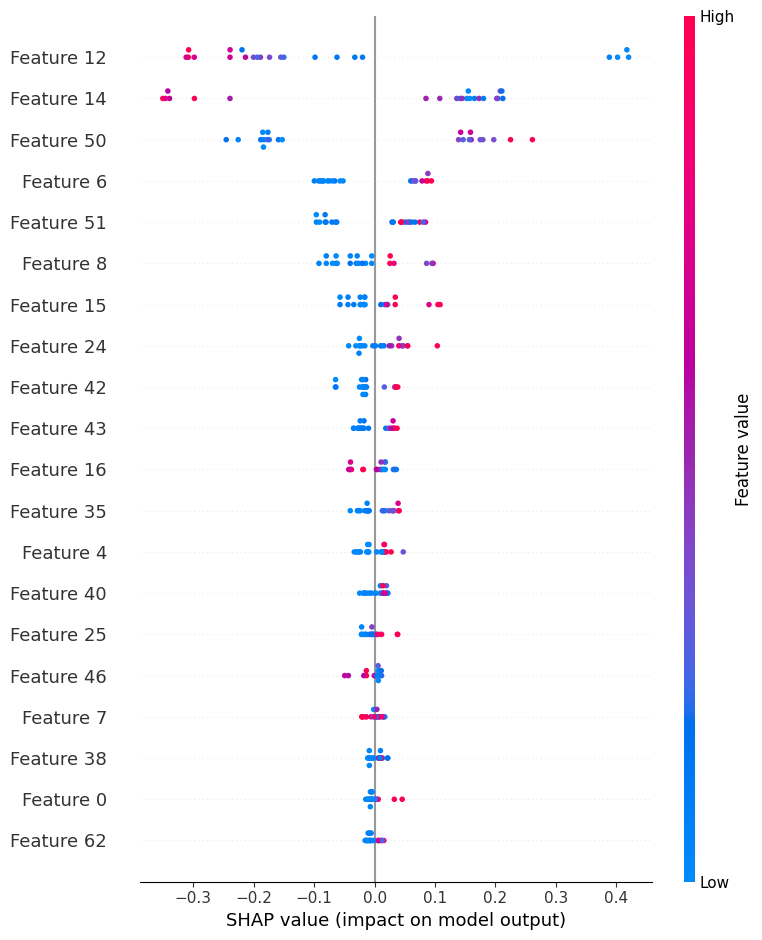

In [ ]:
explainer = shap.Explainer(xgb_model)

shap_values = explainer(test_embeddings)

shap.summary_plot(shap_values, test_embeddings)

**18. Plot Predictions**

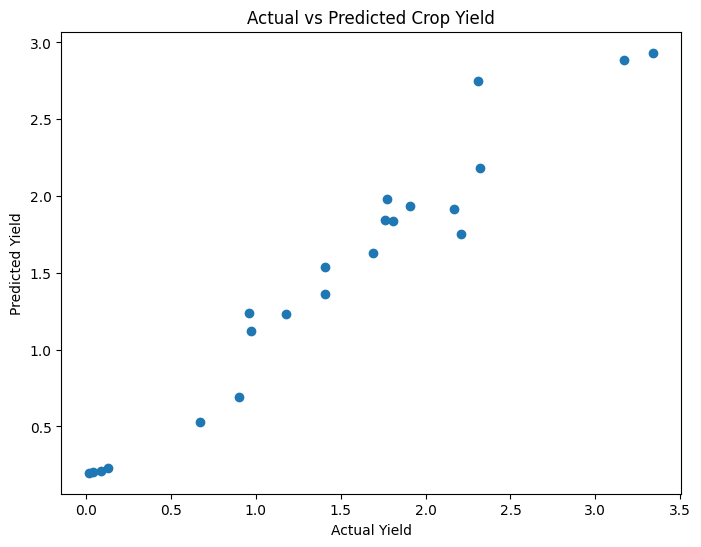

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Crop Yield")

plt.show()

**19. Save Model**

In [ ]:
import joblib

joblib.dump(xgb_model, 'fewshot_crop_yield_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model Saved Successfully")

Model Saved Successfully


**20. Architecture Explanation**



Input Features

       ↓
Feature Engineering

       ↓
Attention-Based Few-Shot Encoder

       ↓
Deep Embedding Space

       ↓
XGBoost Regressor

       ↓

Crop Yield Prediction

       ↓
Uncertainty Estimation + SHAP